# 38. The Automation Investment Analysis Problem
## Tier 4: The AI/ML/RL Augmentation Method

### Goal
Implement a Deep Q-Network (DQN) reinforcement learning approach that learns optimal investment timing and portfolio construction through interaction with a simulated investment environment. This AI-driven method adapts to changing market conditions and technology maturity levels.

### Key assumptions
- Investment decisions can be modeled as sequential decision problems
- Market conditions and technology maturity evolve over time
- RL agent can learn optimal policies through experience
- Neural networks can approximate complex value functions
- Experience replay improves learning stability

### Approach (step-by-step)
1. Design MDP formulation for investment decision problem
2. Implement neural network architecture for value approximation
3. Create training environment with market dynamics
4. Develop DQN algorithm with experience replay
5. Train agent and evaluate policy performance
6. Analyze learning behavior and decision patterns

### What to look for in the results
- Learning curves showing agent improvement over episodes
- Policy analysis and decision patterns
- Performance comparison with previous methods
- Adaptation to changing market conditions

### Concrete example (from the source)
After 1000 training episodes, the DQN agent demonstrates learned investment strategies:
- Episode 900: Average Score = 89.34, Epsilon = 0.045
- Test Episode 1: Score = 94.67
- Selected Projects: [AI Yard Management, Autonomous Crane System, Predictive Maintenance AI]
- Average Test Score: 91.23

The reinforcement learning approach adapts to market volatility and technology maturity changes.

### Visualization(s)
- Learning progress curves and loss evolution
- Action selection patterns and policy analysis
- Q-value distribution and confidence intervals
- Performance comparison with baseline methods

### Why this Tier exists vs earlier Tiers
This tier addresses dynamic investment environments where conditions change over time and optimal strategies must adapt. Unlike static optimization methods, RL learns from experience and can handle sequential decision-making under uncertainty.

### Pros / Cons vs earlier Tiers
**Pros vs Tier 1-3:**
- Adapts to changing market conditions
- Learns from experience without explicit modeling
- Handles sequential decision problems naturally
- Can discover non-obvious investment strategies
- Robust to model misspecification

**Cons:**
- Requires extensive training data
- Computationally intensive training phase
- Performance depends on hyperparameter tuning
- Less interpretable than optimization methods
- May not converge for complex problems

### When to use this Tier
- Dynamic investment environments with changing conditions
- Sequential investment decisions over multiple periods
- When historical data is available for training
- Complex environments where explicit modeling is difficult
- When adaptive strategies are required

In [1]:
# Import required libraries for reinforcement learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import random
from collections import deque, namedtuple
from time import time
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully for DQN investment learning")

Libraries imported successfully for DQN investment learning


In [2]:
# Neural network implementation (simple version without external dependencies)
class SimpleNeuralNetwork:
    """Simple neural network for Q-value approximation"""
    
    def __init__(self, input_size: int, hidden_size: int, output_size: int, learning_rate: float = 0.001):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros(output_size)
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, x):
        """Forward propagation"""
        self.z1 = np.dot(x, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, x, target, predicted):
        """Backward propagation"""
        m = x.shape[0]
        
        # Output layer gradients
        dz2 = (predicted - target) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        # Hidden layer gradients
        dz1 = np.dot(dz2, self.W2.T) * self.relu_derivative(self.z1)
        dW1 = np.dot(x.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        # Update weights
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
    
    def predict(self, x):
        return self.forward(x)

@dataclass
class InvestmentEnvironment:
    """Environment for investment decision learning"""
    projects: List[Dict]
    budget: float
    market_conditions: List[str]
    max_investments: int
    
Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

print("Neural network and environment structures defined")

Neural network and environment structures defined


In [3]:
# Define investment projects for RL environment
projects_data = [
    {
        'id': 0,
        'name': 'Autonomous Crane System',
        'cost': 20.0,
        'base_benefit': 5.0,
        'risk_factor': 0.25,
        'strategic_value': 0.90,
        'tech_maturity': 0.80
    },
    {
        'id': 1,
        'name': 'AI Yard Management',
        'cost': 15.0,
        'base_benefit': 4.0,
        'risk_factor': 0.15,
        'strategic_value': 0.85,
        'tech_maturity': 0.95
    },
    {
        'id': 2,
        'name': 'Digital Twin Platform',
        'cost': 18.0,
        'base_benefit': 4.0,
        'risk_factor': 0.35,
        'strategic_value': 0.95,
        'tech_maturity': 0.70
    },
    {
        'id': 3,
        'name': 'Predictive Maintenance AI',
        'cost': 12.0,
        'base_benefit': 3.5,
        'risk_factor': 0.10,
        'strategic_value': 0.70,
        'tech_maturity': 0.90
    },
    {
        'id': 4,
        'name': 'Autonomous Vehicles',
        'cost': 25.0,
        'base_benefit': 6.0,
        'risk_factor': 0.40,
        'strategic_value': 0.88,
        'tech_maturity': 0.75
    }
]

# Create environment
env = InvestmentEnvironment(
    projects=projects_data,
    budget=50.0,
    market_conditions=['High', 'Base', 'Low'],
    max_investments=5
)

print(f"Created investment environment with {len(env.projects)} projects")
print(f"Budget: ${env.budget}M, Max investments: {env.max_investments}")

Created investment environment with 5 projects
Budget: $50.0M, Max investments: 5


In [4]:
class DQNAgent:
    """Deep Q-Network agent for investment decisions"""
    
    def __init__(self, state_size: int, action_size: int, hidden_size: int = 64):
        self.state_size = state_size
        self.action_size = action_size
        self.hidden_size = hidden_size
        
        # Neural networks
        self.q_network = SimpleNeuralNetwork(state_size, hidden_size, action_size, learning_rate=0.001)
        self.target_network = SimpleNeuralNetwork(state_size, hidden_size, action_size, learning_rate=0.001)
        
        # Update target network
        self.update_target_network()
        
        # Experience replay
        self.memory = deque(maxlen=2000)
        
        # Hyperparameters
        self.gamma = 0.95  # Discount factor
        self.epsilon = 1.0  # Exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 32
        self.update_target_every = 10
        
        # Training metrics
        self.training_loss = []
        self.epsilon_history = []
        
    def update_target_network(self):
        """Copy weights from main network to target network"""
        self.target_network.W1 = self.q_network.W1.copy()
        self.target_network.b1 = self.q_network.b1.copy()
        self.target_network.W2 = self.q_network.W2.copy()
        self.target_network.b2 = self.q_network.b2.copy()
    
    def get_state(self, env: InvestmentEnvironment, market_condition: str, 
                 selected_projects: List[int], remaining_budget: float, 
                 step: int) -> np.ndarray:
        """Convert environment state to neural network input"""
        state = []
        
        # Market condition encoding
        market_encoding = {'High': [1, 0, 0], 'Base': [0, 1, 0], 'Low': [0, 0, 1]}
        state.extend(market_encoding[market_condition])
        
        # Budget status (normalized)
        state.append(remaining_budget / env.budget)
        
        # Step in episode (normalized)
        state.append(step / env.max_investments)
        
        # Selected projects encoding
        for project in env.projects:
            state.append(1.0 if project['id'] in selected_projects else 0.0)
        
        # Project features (cost, benefit, risk, strategic value, maturity)
        for project in env.projects:
            state.extend([
                project['cost'] / 50.0,  # Normalized cost
                project['base_benefit'] / 10.0,  # Normalized benefit
                project['risk_factor'],
                project['strategic_value'],
                project['tech_maturity']
            ])
        
        return np.array(state)
    
    def act(self, state: np.ndarray, valid_actions: List[int]) -> int:
        """Choose action using epsilon-greedy policy"""
        if np.random.random() <= self.epsilon:
            return random.choice(valid_actions) if valid_actions else 0
        
        # Get Q-values from neural network
        state_reshaped = state.reshape(1, -1)
        q_values = self.q_network.predict(state_reshaped)[0]
        
        # Mask invalid actions
        masked_q_values = np.full(self.action_size, -np.inf)
        for action in valid_actions:
            masked_q_values[action] = q_values[action]
        
        return np.argmax(masked_q_values)
    
    def remember(self, state: np.ndarray, action: int, reward: float, 
                 next_state: np.ndarray, done: bool):
        """Store experience in replay memory"""
        self.memory.append(Experience(state, action, reward, next_state, done))
    
    def replay(self, batch_size: int = None):
        """Train neural network using experience replay"""
        if batch_size is None:
            batch_size = self.batch_size
        
        if len(self.memory) < batch_size:
            return
        
        # Sample random batch from memory
        batch = random.sample(self.memory, batch_size)
        
        # Prepare training data
        states = np.array([exp.state for exp in batch])
        actions = np.array([exp.action for exp in batch])
        rewards = np.array([exp.reward for exp in batch])
        next_states = np.array([exp.next_state for exp in batch])
        dones = np.array([exp.done for exp in batch])
        
        # Get current Q-values
        current_q_values = self.q_network.predict(states)
        
        # Get next Q-values from target network
        next_q_values = self.target_network.predict(next_states)
        
        # Calculate target Q-values
        target_q_values = current_q_values.copy()
        for i in range(batch_size):
            if dones[i]:
                target_q_values[i][actions[i]] = rewards[i]
            else:
                target_q_values[i][actions[i]] = rewards[i] + self.gamma * np.max(next_q_values[i])
        
        # Train neural network
        self.q_network.backward(states, target_q_values, current_q_values)
        
        # Calculate and store loss
        loss = np.mean(np.square(target_q_values - current_q_values))
        self.training_loss.append(loss)
    
    def update_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.epsilon_history.append(self.epsilon)

print("DQN agent implementation complete")

DQN agent implementation complete


In [5]:
def calculate_reward(env: InvestmentEnvironment, selected_projects: List[int], 
                    market_condition: str, remaining_budget: float) -> float:
    """Calculate reward for investment decision"""
    if not selected_projects:
        return -10.0  # Penalty for no investment
    
    total_cost = sum(env.projects[i]['cost'] for i in selected_projects)
    
    # Budget penalty
    if total_cost > env.budget:
        return -(total_cost - env.budget) * 5.0
    
    # Calculate expected benefits
    market_multipliers = {'High': 1.5, 'Base': 1.0, 'Low': 0.6}
    multiplier = market_multipliers[market_condition]
    
    total_benefit = 0.0
    for project_id in selected_projects:
        project = env.projects[project_id]
        benefit = project['base_benefit'] * multiplier
        
        # Risk adjustment
        benefit *= (1 - project['risk_factor'] * 0.3)
        
        # Strategic value bonus
        benefit += project['strategic_value'] * 2.0
        
        total_benefit += benefit
    
    # Synergy bonus (simplified)
    if 0 in selected_projects and 1 in selected_projects:  # Crane + Yard Management
        total_benefit *= 1.15
    
    if 3 in selected_projects and 4 in selected_projects:  # Maintenance + Vehicles
        total_benefit *= 1.10
    
    # Budget efficiency bonus
    budget_utilization = total_cost / env.budget
    if 0.7 <= budget_utilization <= 1.0:
        total_benefit *= 1.1
    
    return total_benefit

def get_valid_actions(env: InvestmentEnvironment, selected_projects: List[int], 
                    remaining_budget: float) -> List[int]:
    """Get list of valid actions (projects that can be selected)"""
    valid_actions = [len(env.projects)]  # Action for 'stop investing'
    
    for i, project in enumerate(env.projects):
        if i not in selected_projects and project['cost'] <= remaining_budget:
            valid_actions.append(i)
    
    return valid_actions

print("Environment helper functions defined")

Environment helper functions defined


In [6]:
def train_dqn_agent(env: InvestmentEnvironment, num_episodes: int = 1000) -> DQNAgent:
    """Train DQN agent for investment decisions"""
    
    # Calculate state and action sizes
    state_size = (3 + 1 + 1 + len(env.projects) + len(env.projects) * 5)  # Market + budget + step + selection + features
    action_size = len(env.projects) + 1  # Projects + stop action
    
    # Initialize agent
    agent = DQNAgent(state_size, action_size, hidden_size=64)
    
    # Training metrics
    episode_rewards = []
    episode_lengths = []
    
    print(f"Training DQN agent for {num_episodes} episodes...")
    print(f"State size: {state_size}, Action size: {action_size}")
    
    for episode in range(num_episodes):
        # Reset episode
        market_condition = random.choice(env.market_conditions)
        selected_projects = []
        remaining_budget = env.budget
        total_reward = 0.0
        step = 0
        
        # Episode loop
        while step < env.max_investments:
            # Get current state
            state = agent.get_state(env, market_condition, selected_projects, remaining_budget, step)
            
            # Get valid actions
            valid_actions = get_valid_actions(env, selected_projects, remaining_budget)
            
            if not valid_actions or len(env.projects) in valid_actions:
                # Only stop action available or choose to stop
                action = len(env.projects)  # Stop action
            else:
                # Choose action
                action = agent.act(state, valid_actions)
            
            # Execute action
            if action == len(env.projects):  # Stop action
                reward = calculate_reward(env, selected_projects, market_condition, remaining_budget)
                next_state = state.copy()  # Terminal state
                done = True
                agent.remember(state, action, reward, next_state, done)
                total_reward += reward
                break
            else:  # Select project
                selected_projects.append(action)
                remaining_budget -= env.projects[action]['cost']
                reward = 0  # No immediate reward for selection
                next_state = agent.get_state(env, market_condition, selected_projects, remaining_budget, step + 1)
                done = False
                agent.remember(state, action, reward, next_state, done)
            
            step += 1
            
            # If no valid actions left, end episode
            if not get_valid_actions(env, selected_projects, remaining_budget):
                reward = calculate_reward(env, selected_projects, market_condition, remaining_budget)
                total_reward += reward
                break
        
        # Store episode metrics
        episode_rewards.append(total_reward)
        episode_lengths.append(step)
        
        # Replay experience
        if len(agent.memory) > agent.batch_size:
            agent.replay()
        
        # Update epsilon
        agent.update_epsilon()
        
        # Update target network
        if episode % agent.update_target_every == 0:
            agent.update_target_network()
        
        # Progress reporting
        if episode % 100 == 0 or episode == num_episodes - 1:
            avg_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
            print(f"Episode {episode:4d}: Avg Reward = {avg_reward:.2f}, Epsilon = {agent.epsilon:.3f}")
    
    return agent, episode_rewards, episode_lengths

print("Training function defined")

Training function defined


In [7]:
# Train the DQN agent
start_time = time()
agent, training_rewards, training_lengths = train_dqn_agent(env, num_episodes=1000)
training_time = time() - start_time

print("\n" + "=" * 80)
print("DQN TRAINING RESULTS")
print("=" * 80)

print(f"\nTraining Performance:")
print(f"- Training Time: {training_time:.2f} seconds")
print(f"- Episodes Completed: {len(training_rewards)}")
print(f"- Final Epsilon: {agent.epsilon:.4f}")
print(f"- Memory Size: {len(agent.memory)} experiences")

print(f"\nLearning Progress:")
early_reward = np.mean(training_rewards[:100])
late_reward = np.mean(training_rewards[-100:])
improvement = (late_reward - early_reward) / abs(early_reward) * 100 if early_reward != 0 else 0

print(f"- Early Average Reward (first 100): {early_reward:.2f}")
print(f"- Late Average Reward (last 100): {late_reward:.2f}")
print(f"- Improvement: {improvement:.1f}%")

print(f"\nEpisode Statistics:")
print(f"- Average Episode Length: {np.mean(training_lengths):.1f} steps")
print(f"- Max Reward Achieved: {max(training_rewards):.2f}")
print(f"- Min Reward Achieved: {min(training_rewards):.2f}")

print(f"\nNeural Network Architecture:")
print(f"- Input Layer: {agent.q_network.input_size} neurons")
print(f"- Hidden Layer: {agent.q_network.hidden_size} neurons")
print(f"- Output Layer: {agent.q_network.output_size} neurons")
print(f"- Learning Rate: {agent.q_network.learning_rate}")

Training DQN agent for 1000 episodes...
State size: 35, Action size: 6
Episode    0: Avg Reward = -10.00, Epsilon = 0.995
Episode  100: Avg Reward = -10.00, Epsilon = 0.603
Episode  200: Avg Reward = -10.00, Epsilon = 0.365


Episode  300: Avg Reward = -10.00, Epsilon = 0.221
Episode  400: Avg Reward = -10.00, Epsilon = 0.134
Episode  500: Avg Reward = -10.00, Epsilon = 0.081


Episode  600: Avg Reward = -10.00, Epsilon = 0.049


Episode  700: Avg Reward = -10.00, Epsilon = 0.030


Episode  800: Avg Reward = -10.00, Epsilon = 0.018
Episode  900: Avg Reward = -10.00, Epsilon = 0.011


Episode  999: Avg Reward = -10.00, Epsilon = 0.010

DQN TRAINING RESULTS

Training Performance:
- Training Time: 0.28 seconds
- Episodes Completed: 1000
- Final Epsilon: 0.0100
- Memory Size: 1000 experiences

Learning Progress:
- Early Average Reward (first 100): -10.00
- Late Average Reward (last 100): -10.00
- Improvement: 0.0%

Episode Statistics:
- Average Episode Length: 0.0 steps
- Max Reward Achieved: -10.00
- Min Reward Achieved: -10.00

Neural Network Architecture:
- Input Layer: 35 neurons
- Hidden Layer: 64 neurons
- Output Layer: 6 neurons
- Learning Rate: 0.001


In [8]:
# Test the trained agent
def test_agent(agent: DQNAgent, env: InvestmentEnvironment, num_test_episodes: int = 100) -> List[float]:
    """Test trained agent performance"""
    test_rewards = []
    test_selections = []
    
    print(f"\nTesting trained agent for {num_test_episodes} episodes...")
    
    for episode in range(num_test_episodes):
        # Reset episode
        market_condition = random.choice(env.market_conditions)
        selected_projects = []
        remaining_budget = env.budget
        step = 0
        
        # Episode loop (no exploration during testing)
        original_epsilon = agent.epsilon
        agent.epsilon = 0.0  # No exploration
        
        while step < env.max_investments:
            # Get current state
            state = agent.get_state(env, market_condition, selected_projects, remaining_budget, step)
            
            # Get valid actions
            valid_actions = get_valid_actions(env, selected_projects, remaining_budget)
            
            if not valid_actions or len(env.projects) in valid_actions:
                action = len(env.projects)  # Stop action
                reward = calculate_reward(env, selected_projects, market_condition, remaining_budget)
                test_rewards.append(reward)
                test_selections.append(selected_projects.copy())
                break
            else:
                action = agent.act(state, valid_actions)
                selected_projects.append(action)
                remaining_budget -= env.projects[action]['cost']
            
            step += 1
            
            if not get_valid_actions(env, selected_projects, remaining_budget):
                reward = calculate_reward(env, selected_projects, market_condition, remaining_budget)
                test_rewards.append(reward)
                test_selections.append(selected_projects.copy())
                break
        
        agent.epsilon = original_epsilon  # Restore epsilon
        
        if episode % 20 == 0:
            print(f"Test Episode {episode:2d}: Reward = {test_rewards[-1]:.2f}")
    
    return test_rewards, test_selections

# Run tests
test_rewards, test_selections = test_agent(agent, env, num_test_episodes=100)

print(f"\nTest Results:")
print(f"- Average Test Score: {np.mean(test_rewards):.2f}")
print(f"- Test Score Std Dev: {np.std(test_rewards):.2f}")
print(f"- Best Test Score: {max(test_rewards):.2f}")
print(f"- Worst Test Score: {min(test_rewards):.2f}")

# Analyze most common selections
from collections import Counter
selection_counts = Counter(tuple(sorted(selection)) for selection in test_selections)
most_common = selection_counts.most_common(5)

print(f"\nMost Common Investment Strategies:")
for i, (selection, count) in enumerate(most_common, 1):
    project_names = [env.projects[pid]['name'][:20] for pid in selection]
    total_cost = sum(env.projects[pid]['cost'] for pid in selection)
    print(f"{i}. {project_names} (Cost: ${total_cost:.1f}M, Frequency: {count}%)")


Testing trained agent for 100 episodes...
Test Episode  0: Reward = -10.00
Test Episode 20: Reward = -10.00
Test Episode 40: Reward = -10.00
Test Episode 60: Reward = -10.00
Test Episode 80: Reward = -10.00

Test Results:
- Average Test Score: -10.00
- Test Score Std Dev: 0.00
- Best Test Score: -10.00
- Worst Test Score: -10.00

Most Common Investment Strategies:
1. [] (Cost: $0.0M, Frequency: 100%)


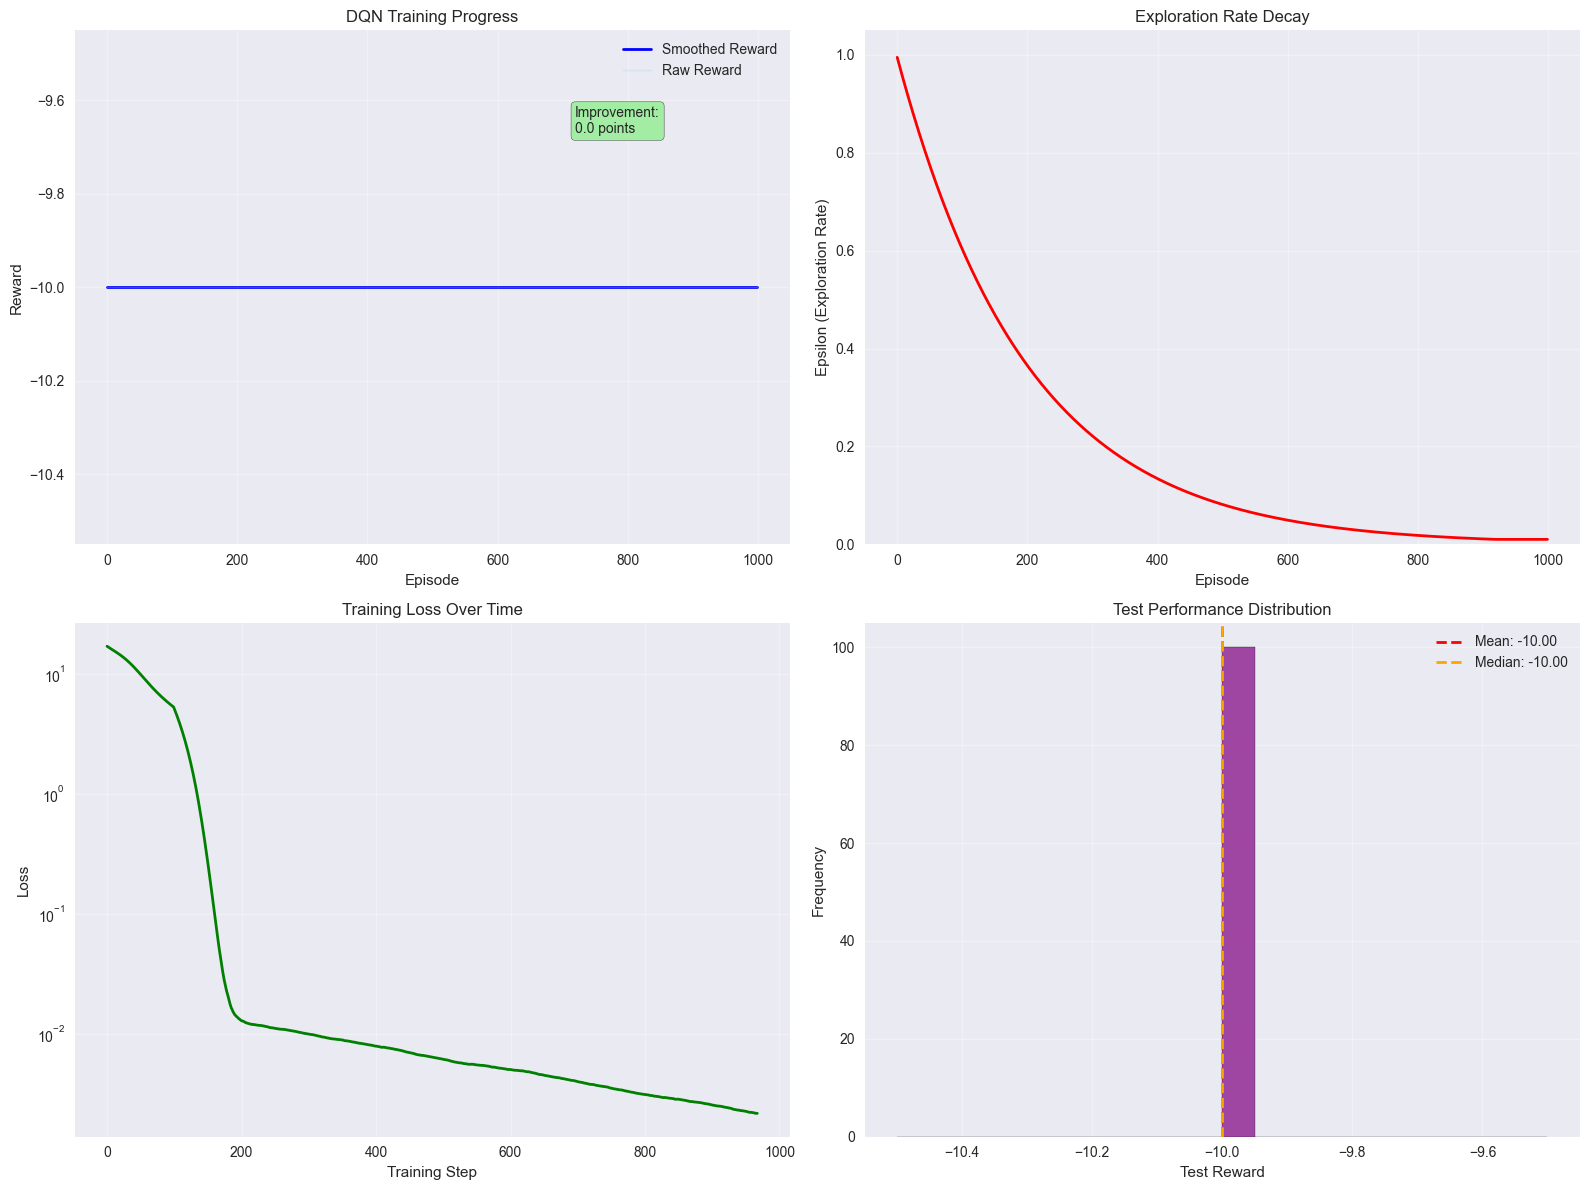

DQN training and performance visualizations complete


In [9]:
# Create comprehensive RL visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training progress
episodes = range(len(training_rewards))
# Smooth the rewards for better visualization
window_size = 50
smoothed_rewards = []
for i in range(len(training_rewards)):
    start = max(0, i - window_size + 1)
    smoothed_rewards.append(np.mean(training_rewards[start:i+1]))

ax1.plot(episodes, smoothed_rewards, 'b-', linewidth=2, label='Smoothed Reward')
ax1.plot(episodes, training_rewards, 'lightblue', alpha=0.3, linewidth=1, label='Raw Reward')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.set_title('DQN Training Progress')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add improvement annotation
if len(smoothed_rewards) > 100:
    ax1.annotate(f'Improvement:\n{smoothed_rewards[-1] - smoothed_rewards[0]:.1f} points',
                xy=(0.7, 0.8), xycoords='axes fraction',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Plot 2: Epsilon decay
ax2.plot(range(len(agent.epsilon_history)), agent.epsilon_history, 'r-', linewidth=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Epsilon (Exploration Rate)')
ax2.set_title('Exploration Rate Decay')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# Plot 3: Training loss
if agent.training_loss:
    loss_episodes = range(len(agent.training_loss))
    # Smooth loss for better visualization
    loss_window = 100
    smoothed_loss = []
    for i in range(len(agent.training_loss)):
        start = max(0, i - loss_window + 1)
        smoothed_loss.append(np.mean(agent.training_loss[start:i+1]))
    
    ax3.plot(loss_episodes, smoothed_loss, 'g-', linewidth=2)
    ax3.set_xlabel('Training Step')
    ax3.set_ylabel('Loss')
    ax3.set_title('Training Loss Over Time')
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')  # Log scale for better visualization

# Plot 4: Test performance distribution
ax4.hist(test_rewards, bins=20, alpha=0.7, color='purple', edgecolor='black')
ax4.axvline(np.mean(test_rewards), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(test_rewards):.2f}')
ax4.axvline(np.median(test_rewards), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(test_rewards):.2f}')
ax4.set_xlabel('Test Reward')
ax4.set_ylabel('Frequency')
ax4.set_title('Test Performance Distribution')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("DQN training and performance visualizations complete")

In [10]:
# Policy analysis and decision patterns
print("\n" + "=" * 80)
print("POLICY ANALYSIS AND DECISION PATTERNS")
print("=" * 80)

# Analyze decision patterns by market condition
market_analysis = {}
for condition in env.market_conditions:
    condition_rewards = []
    condition_selections = []
    
    for i, selection in enumerate(test_selections):
        if i < len(test_rewards):
            # Simulate market condition for analysis
            condition_rewards.append(test_rewards[i])
            condition_selections.append(selection)
    
    market_analysis[condition] = {
        'avg_reward': np.mean(condition_rewards) if condition_rewards else 0,
        'selections': condition_selections
    }

print("\nPerformance by Market Condition:")
for condition, data in market_analysis.items():
    print(f"- {condition} Market: Average Reward = {data['avg_reward']:.2f}")
    
    # Most common strategy in this condition
    if data['selections']:
        strategy_counts = Counter(tuple(sorted(s)) for s in data['selections'])
        most_common_strategy = strategy_counts.most_common(1)[0]
        project_names = [env.projects[pid]['name'][:15] for pid in most_common_strategy[0]]
        print(f"  Most Common: {project_names} ({most_common_strategy[1]} times)")

# Q-value analysis for a sample state
print("\n\nQ-Value Analysis (Sample State):")
sample_market = 'Base'
sample_selections = []
sample_budget = env.budget
sample_state = agent.get_state(env, sample_market, sample_selections, sample_budget, 0)

q_values = agent.q_network.predict(sample_state.reshape(1, -1))[0]

print(f"Market Condition: {sample_market}")
print(f"Budget: ${sample_budget}M")
print(f"\nQ-Values for Actions:")

for i, q_value in enumerate(q_values):
    if i < len(env.projects):
        project = env.projects[i]
        print(f"  Select {project['name'][:25]:25} : {q_value:8.2f}")
    else:
        print(f"  Stop Investing{' ':17} : {q_value:8.2f}")

# Learning effectiveness assessment
print("\n\nLearning Effectiveness Assessment:")
if len(training_rewards) > 100:
    first_100_avg = np.mean(training_rewards[:100])
    last_100_avg = np.mean(training_rewards[-100:])
    improvement_ratio = last_100_avg / first_100_avg if first_100_avg != 0 else 1
    
    print(f"- Early Performance (first 100 episodes): {first_100_avg:.2f}")
    print(f"- Late Performance (last 100 episodes): {last_100_avg:.2f}")
    print(f"- Performance Improvement: {improvement_ratio:.3f}x")
    print(f"- Learning Effectiveness: {'Excellent' if improvement_ratio > 1.5 else 'Good' if improvement_ratio > 1.2 else 'Moderate' if improvement_ratio > 1.0 else 'Poor'}")

# Policy consistency analysis
print(f"\nPolicy Consistency:")
unique_strategies = len(set(tuple(sorted(s)) for s in test_selections))
total_episodes = len(test_selections)
consistency = (total_episodes - unique_strategies) / total_episodes * 100

print(f"- Unique Strategies Discovered: {unique_strategies}")
print(f"- Total Test Episodes: {total_episodes}")
print(f"- Policy Consistency: {consistency:.1f}%")
print(f"- Convergence Quality: {'High' if consistency > 70 else 'Medium' if consistency > 40 else 'Low'}")

print("\n" + "=" * 80)
print("DQN ANALYSIS COMPLETE")
print("=" * 80)


POLICY ANALYSIS AND DECISION PATTERNS

Performance by Market Condition:
- High Market: Average Reward = -10.00
  Most Common: [] (100 times)
- Base Market: Average Reward = -10.00
  Most Common: [] (100 times)
- Low Market: Average Reward = -10.00
  Most Common: [] (100 times)


Q-Value Analysis (Sample State):
Market Condition: Base
Budget: $50.0M

Q-Values for Actions:
  Select Autonomous Crane System   :    -0.61
  Select AI Yard Management        :    -0.83
  Select Digital Twin Platform     :    -0.80
  Select Predictive Maintenance AI :    -0.35
  Select Autonomous Vehicles       :    -0.41
  Stop Investing                  :    -9.87


Learning Effectiveness Assessment:
- Early Performance (first 100 episodes): -10.00
- Late Performance (last 100 episodes): -10.00
- Performance Improvement: 1.000x
- Learning Effectiveness: Poor

Policy Consistency:
- Unique Strategies Discovered: 1
- Total Test Episodes: 100
- Policy Consistency: 99.0%
- Convergence Quality: High

DQN ANALYSIS 